In [24]:
import pandas as pd
import numpy as np
import math

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

import random

from pymongo import MongoClient
import squic

In [25]:
# Set connection
client = MongoClient("mongodb://localhost:27017/")
db = client["bank"]
balances_collection = db["amlsim100"]

In [26]:
# Fetch balance evolution data from MongoDB
cursor = balances_collection.find({}, {"_id": 0})  # Exclude MongoDB item ID

balances = list(cursor)
balances

[{'date': 0,
  'balances': {'0': {'balance': 184.44},
   '1': {'balance': 175.8},
   '2': {'balance': 142.06},
   '3': {'balance': 125.89},
   '4': {'balance': 151.13},
   '5': {'balance': 140.49},
   '6': {'balance': 178.38},
   '7': {'balance': 130.33},
   '8': {'balance': 147.66},
   '9': {'balance': 158.34},
   '10': {'balance': 190.81},
   '11': {'balance': 150.47},
   '12': {'balance': 128.18},
   '13': {'balance': 197.39},
   '14': {'balance': 161.84},
   '15': {'balance': 125.05},
   '16': {'balance': 0.02},
   '17': {'balance': 198.28},
   '18': {'balance': 181.02},
   '19': {'balance': 255.77},
   '20': {'balance': 283.84},
   '21': {'balance': 345.97},
   '22': {'balance': 394.83},
   '23': {'balance': 336.8},
   '24': {'balance': 316.24},
   '25': {'balance': 307.5},
   '26': {'balance': 286.83},
   '27': {'balance': 322.18},
   '28': {'balance': 382.6},
   '29': {'balance': 0.02},
   '30': {'balance': 295.4},
   '31': {'balance': 401.48},
   '32': {'balance': 252.1},
   '3

In [27]:
#df = pd.DataFrame([{**entry["balances"], "date": entry["date"]} for entry in data])

#print(df.shape) # must be (720, 1447)
#print(df.head())

#      | id1 | id2 | ... | id1446
# day1 |   
# day2 |        balances
# ...

In [28]:
#df

In [29]:
# Check the number of unique dates in extracted data
dates = [entry["date"] for entry in balances]
print("Unique dates found:", len(set(dates)))  # Should be 720
print("First 5 dates:", sorted(set(dates))[:5])
print("Last 5 dates:", sorted(set(dates))[-5:])

Unique dates found: 200
First 5 dates: [0, 1, 2, 3, 4]
Last 5 dates: [195, 196, 197, 198, 199]


In [30]:
df = pd.DataFrame([
    {key: value["balance"] for key, value in entry["balances"].items()} | {"date": entry["date"]}
    for entry in balances
])

# Convert "date" to datetime and set as index
df.set_index("date", inplace=True)
df.sort_index(inplace=True)

In [31]:
df

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
date,,,,,,,,,,,,,,,,,,,,,
0,184.44,175.80,142.06,125.89,151.13,140.49,178.38,130.33,147.66,158.34,...,411.76,331.00,340.34,426.02,463.36,411.81,437.84,238.28,386.67,297.29
1,184.44,0.00,142.06,125.89,182.79,140.49,194.34,130.33,163.62,31.70,...,411.76,346.06,356.30,426.02,463.36,411.81,452.90,238.28,386.67,297.29
2,253.63,12.38,142.06,138.27,195.17,217.43,194.34,130.33,163.62,92.89,...,485.33,425.57,356.30,426.02,475.74,578.08,452.90,307.47,416.62,12.55
3,322.82,12.38,142.06,138.27,195.17,217.43,264.42,164.84,163.62,92.89,...,517.69,425.57,356.30,461.13,475.74,647.27,452.90,406.85,551.40,147.33
4,322.82,22.28,198.79,138.27,283.92,76.94,264.42,202.88,163.62,92.89,...,758.87,493.80,137.97,478.19,592.32,702.29,165.99,637.58,681.07,272.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1312.03,-3998.92,-1015.09,-929.73,759.18,175.20,-68.40,131.37,-953.47,-445.13,...,6129.84,2741.40,6605.25,3671.52,1318.73,5914.94,7758.35,9444.49,11741.15,11217.91
196,-1312.03,-3998.92,-1157.14,-929.73,759.18,175.20,-68.40,131.37,-953.47,-445.13,...,6129.84,2754.61,6605.25,3709.68,1318.73,5932.86,7897.52,9457.70,11788.50,11285.84
197,-1312.03,-3998.92,-1299.19,-929.73,639.73,175.20,-68.40,131.37,-953.47,-571.77,...,5823.71,2800.86,6641.93,3833.55,1418.36,5990.27,8095.31,9607.42,11959.72,11468.65


In [32]:
df['1']

date
0       175.80
1         0.00
2        12.38
3        12.38
4        22.28
        ...   
195   -3998.92
196   -3998.92
197   -3998.92
198   -3998.92
199   -3986.54
Name: 1, Length: 200, dtype: float64

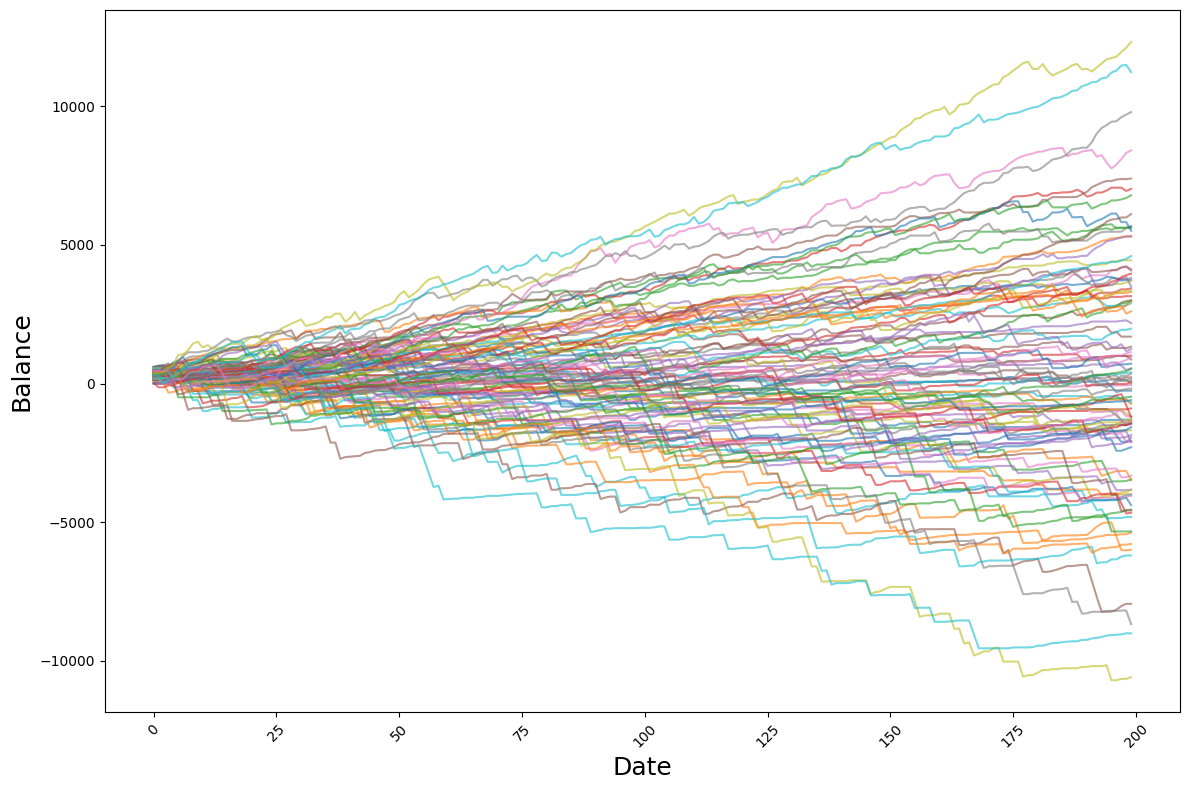

In [33]:
# Plot the balance evolution for all users (columns) as separate lines
plt.figure(figsize=(12, 8))

# Plot each column (account balance) as a line
for user in df.columns:
    plt.plot(df.index, df[user], label=f"User {user}", alpha=0.6)

# Add title and labels
# plt.title("Balance Evolution of Users Over Time")
plt.xlabel("Date", fontsize=18)
plt.ylabel("Balance", fontsize=18)

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45)

# Add legend to differentiate users
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

# Balance Distribution

### First and last day

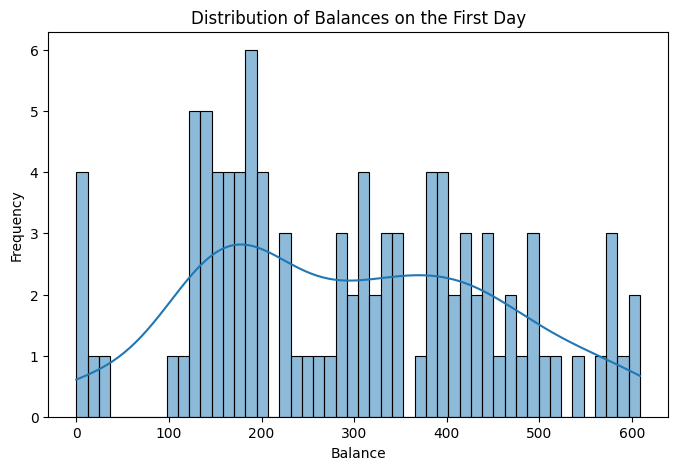

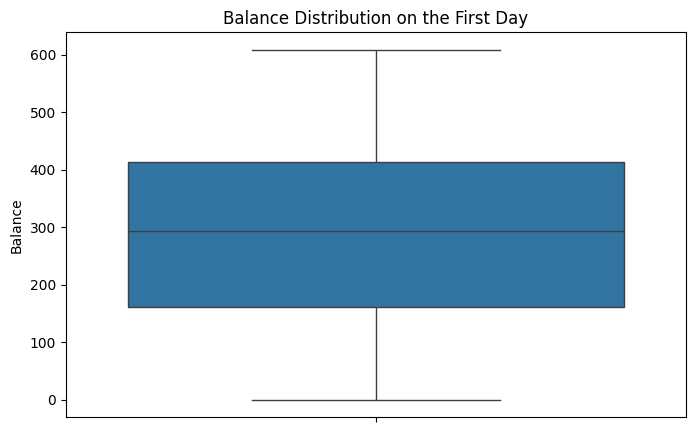

In [34]:
# Select the balances on the first day
first_day_balances = df.iloc[0]

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(first_day_balances, bins=50, kde=True)
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Balances on the First Day")
plt.show()

# Plot box plot
plt.figure(figsize=(8, 5))
sns.boxplot(y=first_day_balances)
plt.ylabel("Balance")
plt.title("Balance Distribution on the First Day")
plt.show()

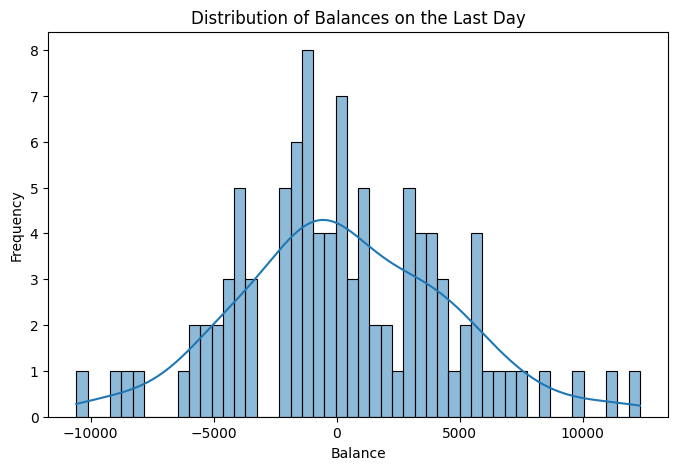

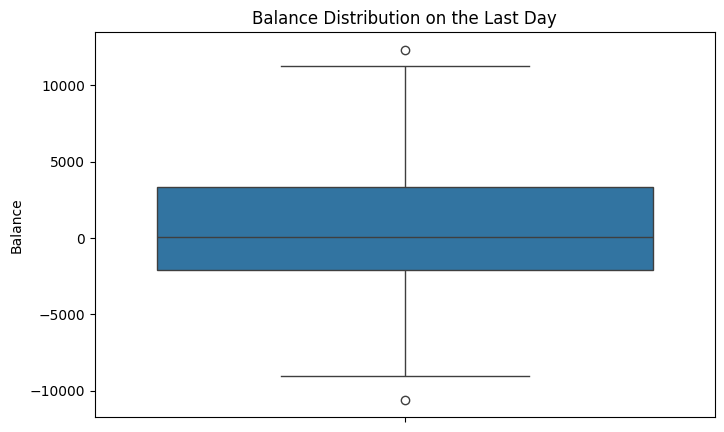

In [35]:
# Select the balances on the first day
last_day_balances = df.iloc[-1]

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(last_day_balances, bins=50, kde=True)
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Balances on the Last Day")
plt.show()

# Plot box plot
plt.figure(figsize=(8, 5))
sns.boxplot(y=last_day_balances)
plt.ylabel("Balance")
plt.title("Balance Distribution on the Last Day")
plt.show()

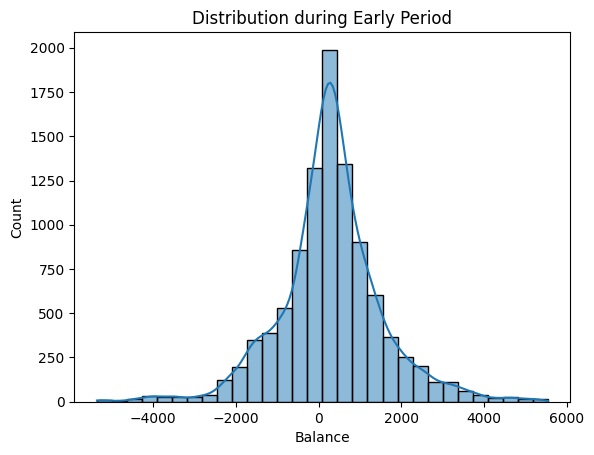

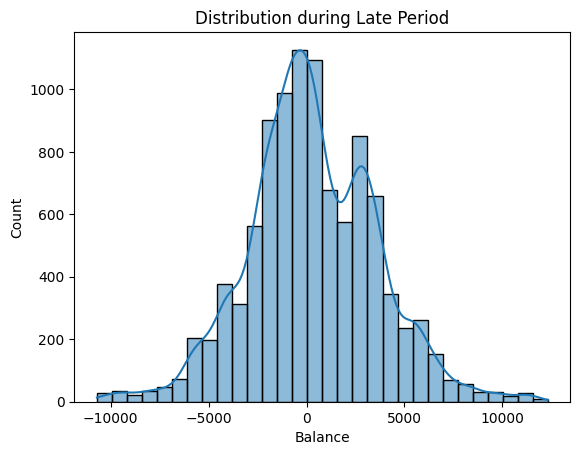

In [36]:
# Split the DataFrame into two parts
early_period = df.iloc[:int(0.5 * len(df))]
late_period  = df.iloc[int(0.5 * len(df)):]

# Plot distribution for early days (aggregated over users and days)
sns.histplot(early_period.values.flatten(), bins=30, kde=True)
plt.title("Distribution during Early Period")
plt.xlabel("Balance")
plt.show()

# Plot distribution for late days
sns.histplot(late_period.values.flatten(), bins=30, kde=True)
plt.title("Distribution during Late Period")
plt.xlabel("Balance")
plt.show()

### Total Distribution

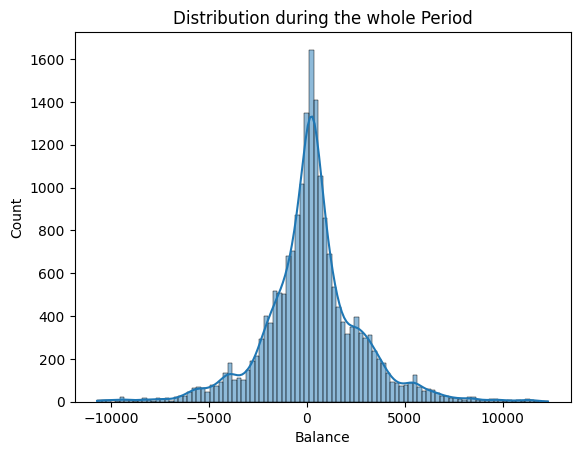

In [37]:
values_df = df.values.flatten()
# Plot distribution for all the days (aggregated over users and days)
sns.histplot(values_df, bins=100, kde=True)
plt.title("Distribution during the whole Period")
plt.xlabel("Balance")
plt.show()

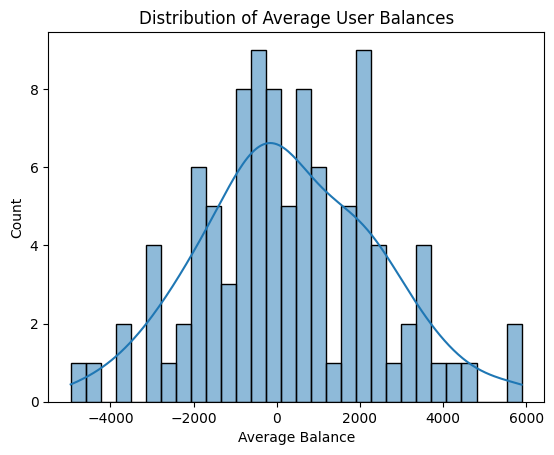

In [38]:
# Compute the mean balance per user over all days
user_means = df.mean(axis=0)

sns.histplot(user_means, bins=30, kde=True)
plt.title("Distribution of Average User Balances")
plt.xlabel("Average Balance")
plt.show()

# Squic

In [39]:
def compute_squic(df, l):
    Y = df.T.to_numpy()  # Transpose to get shape (users, days)

    [X,W,info_times,info_objective,info_logdetX,info_trSX] = squic.run(Y,l)

    print(X.todense())
    return X

def count_zero(X):
    # Count nonzero elements in X
    num_nonzero = X.nnz

    # Compute sparsity level
    total_elements = X.shape[0] * X.shape[1]
    sparsity = num_nonzero / total_elements

    print(f"Number of nonzero elements: {num_nonzero}")
    print(f"Sparsity level: {sparsity:.4f}")

def nnz(X):
    # Count nonzero elements in X
    return X.nnz

def sparsity_pattern(X):
    plt.figure(figsize=(10, 10))
    plt.spy(X, markersize=5)  # Adjust markersize for better visibility
    plt.xlabel("Users", fontsize=18)
    plt.ylabel("Users", fontsize=18)
    # plt.title("Sparsity Pattern of Precision Matrix (X)")
    plt.show()

In [40]:
df.T

date,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,184.44,184.44,253.63,322.82,322.82,322.82,322.82,374.37,374.37,374.37,...,-1450.41,-1450.41,-1381.22,-1312.03,-1312.03,-1312.03,-1312.03,-1312.03,-1496.47,-1427.28
1,175.80,0.00,12.38,12.38,22.28,22.28,32.18,32.18,32.18,32.18,...,-3823.12,-3823.12,-3823.12,-3998.92,-3998.92,-3998.92,-3998.92,-3998.92,-3998.92,-3986.54
2,142.06,142.06,142.06,142.06,198.79,56.74,66.64,66.64,-28.58,-28.58,...,-919.87,-919.87,-919.87,-919.87,-919.87,-1015.09,-1157.14,-1299.19,-1299.19,-1299.19
3,125.89,125.89,138.27,138.27,138.27,138.27,138.27,138.27,178.23,218.19,...,-989.31,-929.73,-929.73,-929.73,-929.73,-929.73,-929.73,-929.73,-929.73,-897.73
4,151.13,182.79,195.17,195.17,283.92,204.50,204.50,204.50,204.50,236.16,...,638.77,687.49,687.49,687.49,687.49,759.18,759.18,639.73,488.62,532.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,411.81,411.81,578.08,647.27,702.29,738.97,738.97,839.29,855.04,870.79,...,5302.29,5467.55,5565.16,5685.16,5838.99,5914.94,5932.86,5990.27,5990.27,6112.25
96,437.84,452.90,452.90,452.90,165.99,159.13,159.13,369.29,433.40,433.40,...,8397.31,8426.50,8186.50,8237.63,7969.31,7758.35,7897.52,8095.31,8317.07,8411.27
97,238.28,238.28,307.47,406.85,637.58,807.53,997.13,1126.93,1126.93,1126.93,...,8504.86,8706.56,9016.88,9218.89,9317.82,9444.49,9457.70,9607.42,9701.23,9790.04
98,386.67,386.67,416.62,551.40,681.07,1032.70,1054.83,1201.22,1443.05,1505.01,...,11352.51,11255.45,11399.45,11549.06,11693.80,11741.15,11788.50,11959.72,12111.11,12321.77


In [41]:
l = [.4, 1e-1, 1e-2, 1e-3, 1e-4]

## Squic DF

In [42]:
rho_dict = {}

not returning good results, one big block

In [43]:
# for rho in l:
#     X_df = compute_squic(df, rho)
#     rho_dict[rho] = X_df

#     count_zero(rho_dict[rho])

#     if nnz(rho_dict[rho]) != len(df.columns):
#         print(f"For rho = {rho} there are some nnz")
#         sparsity_pattern(rho_dict[rho])
#     else:
#         print(f"For rho = {rho} just element on the diagonal")

# Squic-Run

In [44]:
def squic_fit(Y, lambda_val, eta, kappa=0, tau=0):
    # # First squic call -> Identify negative off-diagonal elements (Equation 9)
    X1, _, _, _, _, _ = squic.run(Y, lambda_val)
    Theta1 = X1.todense()
    
    # Step 2: Build Graphical Bias G (Equation 10)
    G = np.zeros_like(Theta1)
    G[np.triu_indices_from(G, k=1)] = (Theta1[np.triu_indices_from(Theta1, k=1)] < -kappa).astype(int)
    G += G.T  # Make symmetric
    
    # Step 3: Build Regularization Parameter Matrix Λ (Equation 12)
    #Lambda = np.full_like(Theta1, lambda_val) 
    Lambda = np.zeros_like(Theta1)
    # Apply eta where G is nonzero
    Lambda[G != 0] = eta
    
    # Step 4: Second SQUIC estimation with bias (Equation 11)
    X2, _, _, _, _, _ = squic.run(Y, lambda_val, M=Lambda)
    Theta2 = X2.todense()
    
    # Step 5: Construct the final M-matrix (Equation 13)
    Theta_final = np.zeros_like(Theta2)
    
    # Get diagonal
    diag = np.diag(Theta2)
    
    # Identify negative off-diagonal elements
    n = Theta2.shape[0]
    for i in range(n):
        for j in range(i+1, n):
            if Theta2[i, j] < -tau:
                Theta_final[i, j] = Theta2[i, j]
                Theta_final[j, i] = Theta2[j, i]
    
    # Restore diagonal
    np.fill_diagonal(Theta_final, diag)
    
    return Theta_final

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.12e-03 nnz(S)/p=1.00e+02
* iter=1 time=1.39e-02 obj=7.43e+07 |delta(obj)|/obj=1.37e+00 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.04e+00] lns_iter=29 
* iter=2 time=5.84e-03 obj=2.95e+07 |delta(obj)|/obj=1.51e+00 nnz(X,L,W)/p=[1.00e+02 5.00e+01 6.29e+01] lns_iter=30 
* iter=3 time=2.34e-02 obj=1.77e+07 |delta(obj)|/

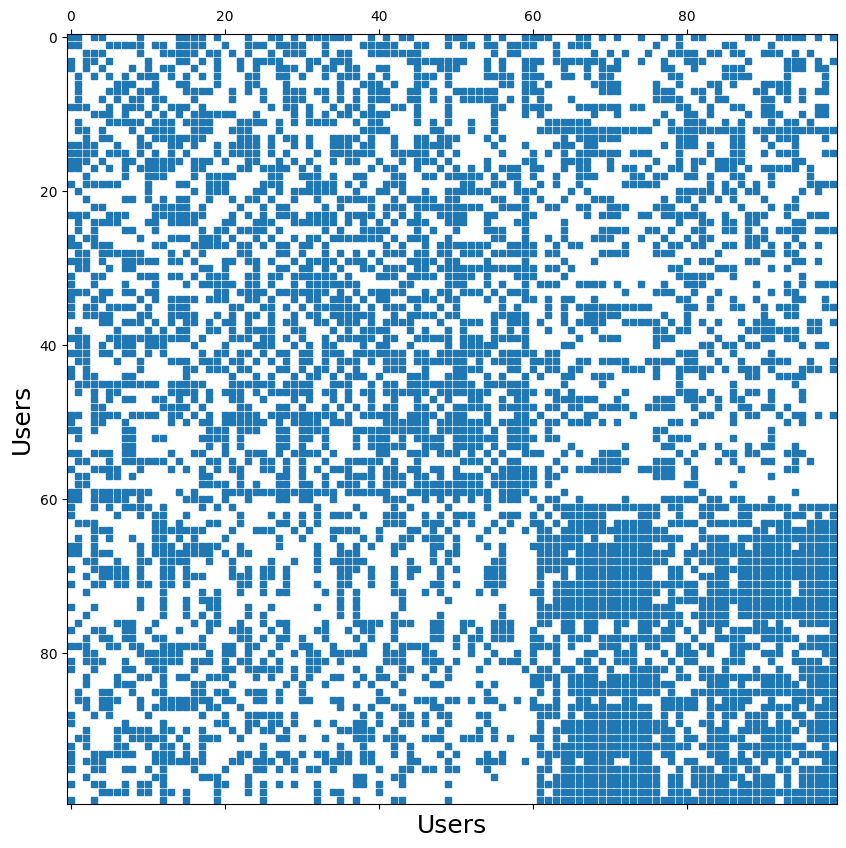

In [46]:
Y = df.T.to_numpy()  # Convert to (users, days)
theta = squic_fit(Y, lambda_val=1e-6, eta=1e-7)
sparsity_pattern(theta)

In [47]:
import numpy as np
import scipy.sparse as sp

def squic_matlab(Y, lambda_val, eta):
    # Get dimensions
    p, _ = Y.shape
    
    # Construct initial Lambda matrix (zero sparse matrix)
    Lambda_matrix = sp.csr_matrix((p, p))

    # W0 = Lambda_matrix
    # X0 = Lambda_matrix
    
    print('Squic Run 1: Estimate graphical bias of negatively correlated variables')
    
    # First SQUIC call
    X1, _, _, _, _, _ = squic.run(Y, lambda_val, M=Lambda_matrix)
    
    # Remove diagonal entries and select structure of negative off-diagonal entries
    G_neg = X1.todense() - np.diag(np.diag(X1.todense()))
    G_neg = (G_neg < 0).astype(float)
    
    print('Squic Run 2: Use the graphical bias and select negatively correlated variables')
    
    # Construct Lambda matrix
    Lambda_matrix = sp.csr_matrix(eta * G_neg)
    
    # Second SQUIC call
    X2,  _, _, _, _, _ = squic.run(Y, lambda_val, M=Lambda_matrix)
    
    # Remove diagonal entries
    W = X2.todense() - np.diag(np.diag(X2.todense()))
    
    # Create the adjacency matrix with weights
    #  Select the negative off-diagonal entries
    W = np.abs(W) * (W < 0)
    
    return W

In [48]:
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.41e-04 nnz(S)/p=1.00e+02
* iter=1 time=2.78e-03 obj=5.64e+01 |delta(obj)|/obj=7.72e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=5.07e-03 obj=3.57e+01 |delta(obj)|/obj=5.81e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 9.31e+01] lns_iter=9 
* iter=3 time=3.05e-02 obj=2.22e+01 |delta(obj)|/ob

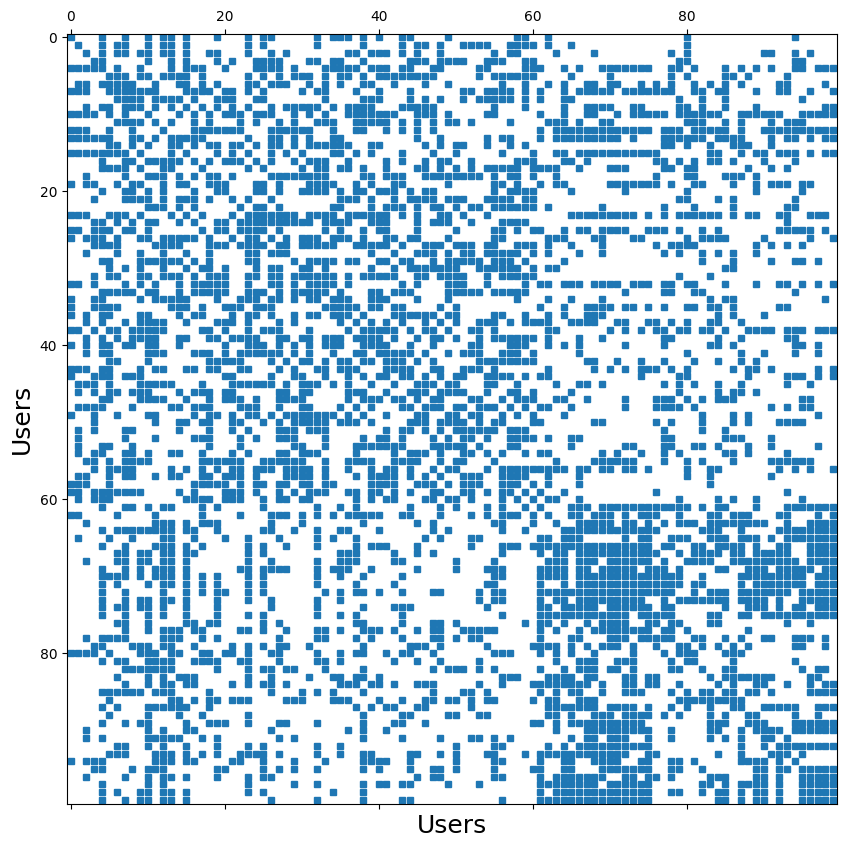

In [49]:
theta2 = squic_fit(Y_new, lambda_val=1e-3, eta=1e-4)
sparsity_pattern(theta2)

In [50]:
theta2

matrix([[71.16666854,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        , 55.12293347,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        , 21.49923983, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        , ..., 52.04580489,
         -0.99096211, -1.2711005 ],
        [ 0.        ,  0.        ,  0.        , ..., -0.99096211,
         52.84731333, -1.62659535],
        [ 0.        ,  0.        ,  0.        , ..., -1.2711005 ,
         -1.62659535, 53.70542835]])

In [51]:
theta

matrix([[ 0.93233298, -0.0088585 ,  0.        , ..., -0.00443038,
          0.        , -0.00753638],
        [-0.0088585 ,  0.96751158,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.91497164, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [-0.00443038,  0.        ,  0.        , ...,  0.95455939,
         -0.03703502, -0.04413016],
        [ 0.        ,  0.        ,  0.        , ..., -0.03703502,
          0.8990222 , -0.08239648],
        [-0.00753638,  0.        ,  0.        , ..., -0.04413016,
         -0.08239648,  0.98895094]])

# Create Graph

In [80]:
# Ensure all off-diagonal entries are positive
theta = np.abs(theta) 

# Ensure diagonal entries are zero
np.fill_diagonal(theta, 0)

In [82]:
import networkx as nx

G = nx.from_numpy_array(theta)

Any NaNs in G adjacency matrix? False
Any infinities? False


In [87]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import SpectralClustering, DBSCAN

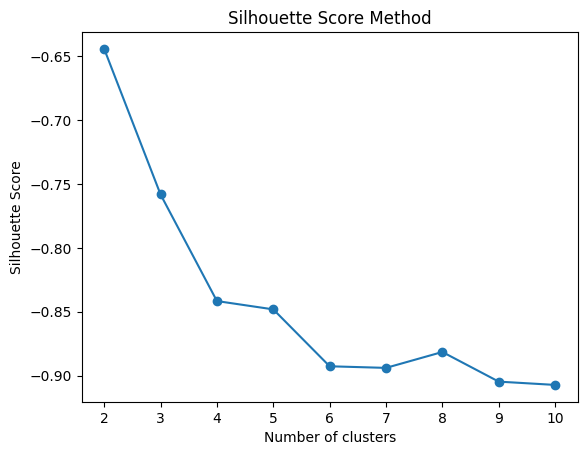

In [83]:
cluster_range = range(2, 11)
sil_scores = []

for n in cluster_range:
    # Perform SpectralClustering
    clustering = SpectralClustering(n_clusters=n, affinity='precomputed', assign_labels='cluster_qr')
    labels = clustering.fit_predict(np.asarray(theta))
    
    # Compute the Silhouette Score
    sil_score = silhouette_score(np.asarray(theta), labels, metric='precomputed')
    sil_scores.append(sil_score)

# Plot Silhouette Score for each number of clusters
plt.plot(cluster_range, sil_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Method')
plt.show()

In [84]:
n_clusters = 6
clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', assign_labels='cluster_qr')
labels = clustering.fit_predict(np.asarray(theta))


In [85]:
# Convert the labels to a DataFrame (node indices and their cluster labels)
df_labels = pd.DataFrame({
    'Node': range(len(labels)),
    'Cluster': labels
})

df_labels.to_csv('clustered_nodes.csv', index=False)

In [86]:
df_labels

,Node,Cluster
0,0,5
1,1,1
2,2,4
3,3,5
4,4,5
...,...,...
95,95,0
96,96,3
97,97,3
98,98,3


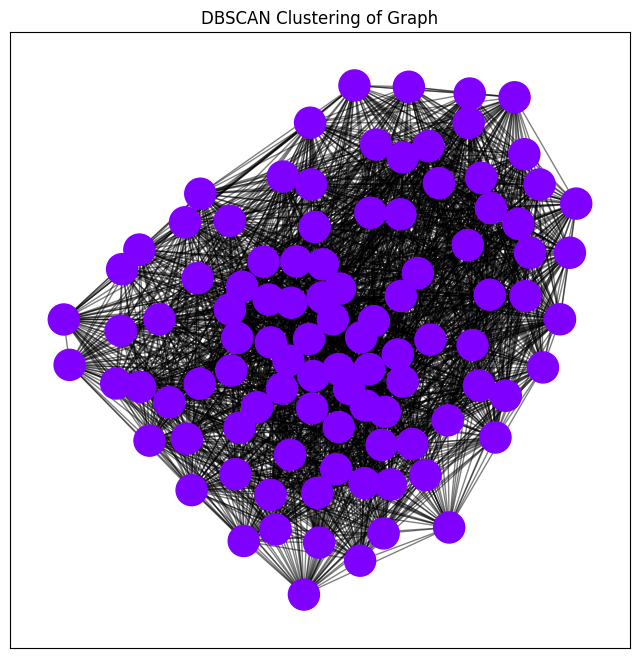

Cluster labels for each node: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [98]:
# Run DBSCAN
eps_value = 0.1  # You may need to adjust this based on your data
min_samples = 2  # Minimum samples per cluster

# Perform DBSCAN clustering on the adjacency matrix (theta)
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples, metric='precomputed')
labels = dbscan.fit_predict(np.asarray(theta))

# Assign DBSCAN cluster labels to nodes as node attributes
for i, label in enumerate(labels):
    G.nodes[i]['cluster'] = label  # Label nodes with their cluster

# Optional: Visualize the clusters (only works for small graphs)
pos = nx.spring_layout(G)
plt.figure(figsize=(8, 8))
nx.draw_networkx_nodes(G, pos, node_size=500, cmap=plt.cm.rainbow, node_color=labels)
nx.draw_networkx_edges(G, pos, alpha=0.5)
plt.title("DBSCAN Clustering of Graph")
plt.show()

# You can also check the clusters
print("Cluster labels for each node:", labels)
